# Model Fitness

### Descripción del proyecto

La cadena de gimnasios  está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.


En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Este proyecto consiste en analizarlos y elaborar una estrategia de retención de clientes.

### 1° Etapa: Descargamos los datos

Model Fitness aportó un archivos CSV que contienen los datos sobre la cancelación de un mes en concreto e información del mes que lo precedía. El dataset incluye los siguientes campos:

- Datos del usuario del mes anterior: 
- 'gender'.
- 'Near_Location' — si el/la usuario/a vive o trabaja en el vecindario donde se encuentra el gimnasio.
- 'Partner' — si el/la usuario/a trabaja en una compañía asociada (el gimnasio tiene empresas asociadas cuyos empleados obtienen descuentos; en esos casos el gimnasio almacena información sobre los empleadores de los clientes).
- Promo_friends — si el/la usuario/a originalmente se inscribió mediante una oferta “trae a un/a amigo/a” (se utilizó el código promocional de un/a amigo/a cuando pagaron el primer abono).
- 'Phone' — si el/la usuario/a aportó el número de teléfono.
- 'Age'.
- 'Lifetime' — el tiempo (en meses) desde que el/la usuario/a llegó por primera vez al gimnasio.
- 'Churn' — la cancelación para el mes en cuestión


Datos del registro de visitas y compras y datos sobre el estado actual de la membresía:
- 'Contract_period' — 1 mes, 3 meses, 6 meses o 1 año.
- 'Month_to_end_contract' — los meses que faltan hasta que expire el contrato.
- 'Group_visits' — si el/la usuario/a participa en sesiones grupales.
- 'Avg_class_frequency_total' — frecuencia media de visitas por semana a lo largo de la vida del cliente.
- 'Avg_class_frequency_current_month' — frecuencia media de visitas por semana durante el mes en curso.
- 'Avg_additional_charges_total' — cantidad total de dinero gastado en otros servicios del gimnasio: cafetería, productos deportivos, cosméticos, masajes, etc.

In [1]:
#importamos librerias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
#cargamos datos 
data = pd.read_csv('gym_churn_us.csv')

### 2° Etapa: Análisis Exploratorio de Datos (EDA)


In [3]:
#observo tamaño del data set y una muestra aleatoria de 5 filas
print("Dimensiones del dataset:", data.shape)
display(data.sample(5))

Dimensiones del dataset: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
2349,0,1,0,0,1,1,0,30,106.429668,1.0,3,2.427255,1.909613,1
293,0,1,0,0,1,1,0,31,104.917041,1.0,0,1.195440,0.247636,1
1962,1,1,1,0,1,12,1,33,16.493167,12.0,4,1.718790,1.853020,0
325,0,1,1,1,1,6,0,30,26.058536,6.0,4,1.533891,1.501383,0
917,1,0,0,0,1,1,0,25,168.609715,1.0,1,1.625422,0.852373,1


In [ ]:
#cambio nombre de columnas para que al graficar sea más facil ver sus nombres:
data.columns = ['gender', 'near', 'partner', 'promo', 'phone', 'contract_for', 'group', 'age', 'extra_cost', 'ending_in', 'lifetime', 'avg_freq', 'avg_month', 'churn']

In [5]:
#información resumida del dataset y observo si hay valores nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   gender        4000 non-null   int64  
 1   near          4000 non-null   int64  
 2   partner       4000 non-null   int64  
 3   promo         4000 non-null   int64  
 4   phone         4000 non-null   int64  
 5   contract_for  4000 non-null   int64  
 6   group         4000 non-null   int64  
 7   age           4000 non-null   int64  
 8   extra_cost    4000 non-null   float64
 9   ending_in     4000 non-null   float64
 10  lifetime      4000 non-null   int64  
 11  avg_freq      4000 non-null   float64
 12  avg_month     4000 non-null   float64
 13  churn         4000 non-null   int64  
dtypes: float64(4), int64(10)
memory usage: 437.6 KB


No se observan datos nulos. 

Como observación en la columna: month to end contract, aparece como float number pero solo se observan numeros enteros, por esto mismo se decide cambiar el tipo de datos a interger

In [6]:
# eliminamos las filas con los valores duplicados e imprimimos el tamaño del DataFrame actualizado
data.drop_duplicates(inplace = True)
print(data.shape)

(4000, 14)


No se observan datos duplicados

In [7]:
#cambio el tipo de datos de la columna 'ending_in' a entero
data['ending_in'] = data['ending_in'].astype('int')


In [8]:
#observo valores promedio y la desviación estándar con el método describe()
display(data.describe())

,gender,near,partner,promo,phone,contract_for,group,age,extra_cost,ending_in,lifetime,avg_freq,avg_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [9]:
#Observo los valores medios de las características en dos grupos: para las personas que se fueron  y para las que se quedaron en el gimnasio
churn = data.groupby('churn').mean()
display(churn)

,gender,near,partner,promo,phone,contract_for,group,age,extra_cost,ending_in,lifetime,avg_freq,avg_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


0 corresponde a los clientes que se quedan, es decir que NO cancelaron su subscripcion.  En tanto 1 es aquellos que sí han cancelado.

Se puede decir en términos generales que los usuarios que cancelan sus subscripciones tienen una media de 1.7 meses, lo que nos haría suponer que los contratos que utilizan son de 1 o 3 meses. La participación en sesiones grupales y la frecuencia media de visitas por semana durante el mes en curso es 50% menos que en los que continúan con su subscripción.


In [10]:
#Graficamos histogramas de barras y distribuciones de características para aquellas personas que se fueron y para las que se quedaron.

#primero creo 2 dataframes, uno para los que se quedaron y otro para los que se fueron
data_cancelled = data[data['churn'] == 1]
data_continue = data[data['churn'] == 0]

#defino una función para graficar histogramas y distribuciones

def histograma_comparativo(columna, title, x,y):
    plt.figure(figsize=(15, 5))
    sns.histplot(data=data_continue[columna], label='Continúan', fill=True, color='purple', kde=True, bins=x)
    sns.histplot(data=data_cancelled[columna], label='Cancelaron', fill=True, color='red', kde=True, bins=y)
    plt.title(f'Distribución comparativa: {title}')
    plt.legend()
    plt.tight_layout()
    plt.show()

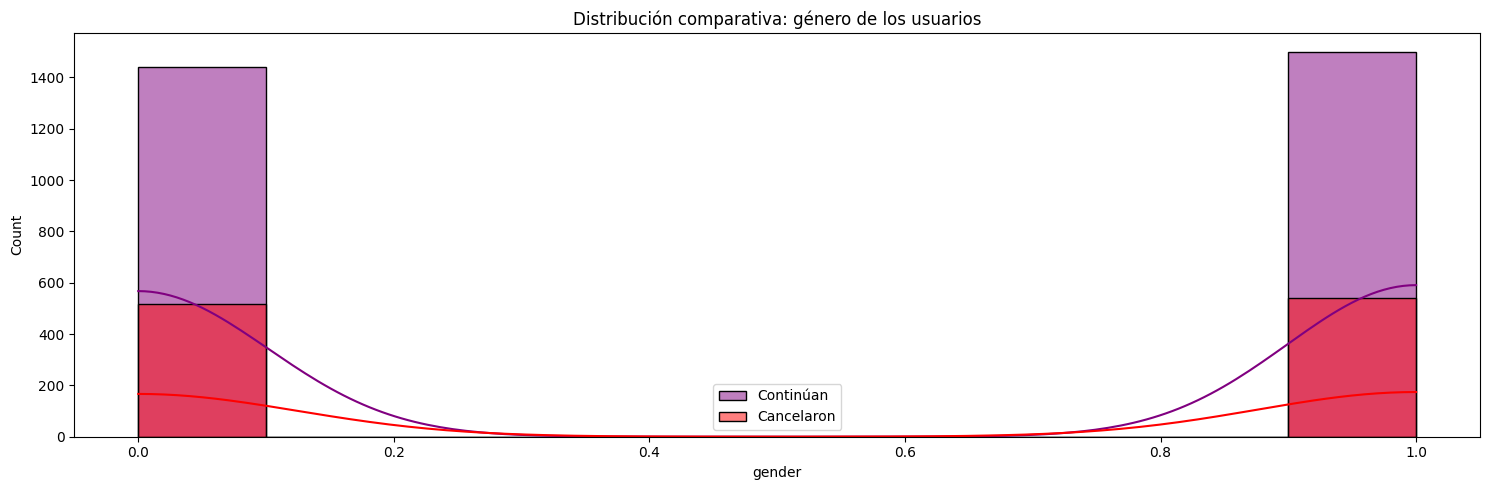

In [11]:
histograma_comparativo('gender', 'género de los usuarios', 10, 10)
# 0 corresponde a hombres y 1 corresponde a mujeres

No se observan diferencias significativas en la cantidad de hombres o mujeres que cancelan su subscripción. 

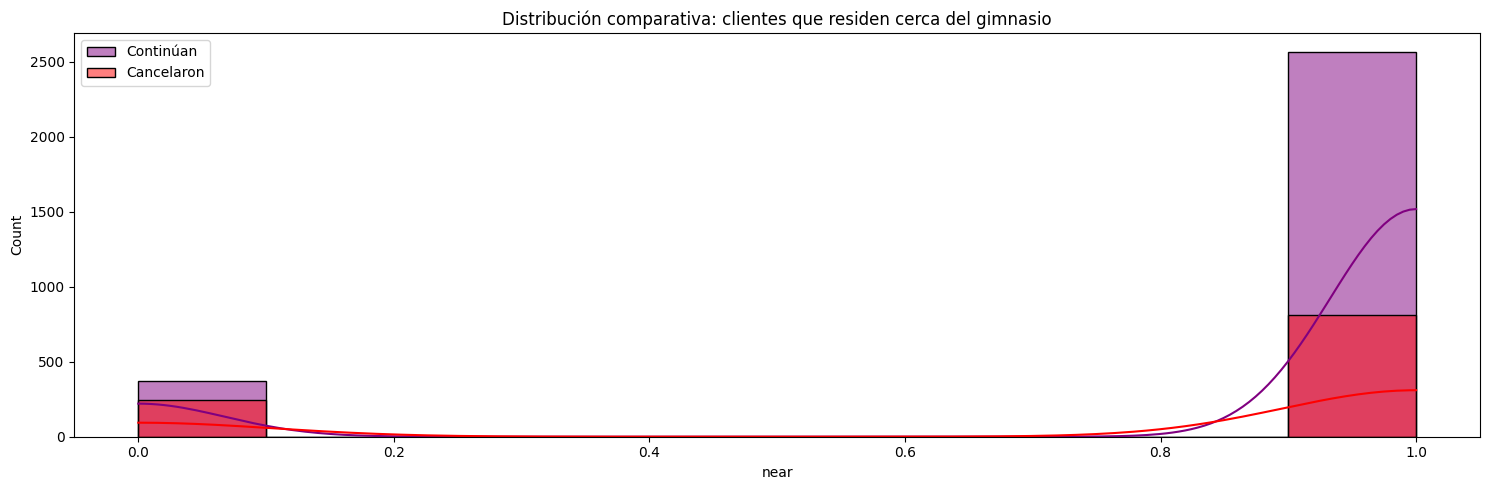

In [12]:
histograma_comparativo('near', 'clientes que residen cerca del gimnasio', 10, 10)
# 0 corresponde a que no residen cerca del gimnasio y 1 que sí residen cerca del gimnasio

Comparando las barras en los gráficos, teniendo en cuenta la densidad de frecuencia, hay mayor tendencia a que cancelen quienes viven lejos del gimnasio.

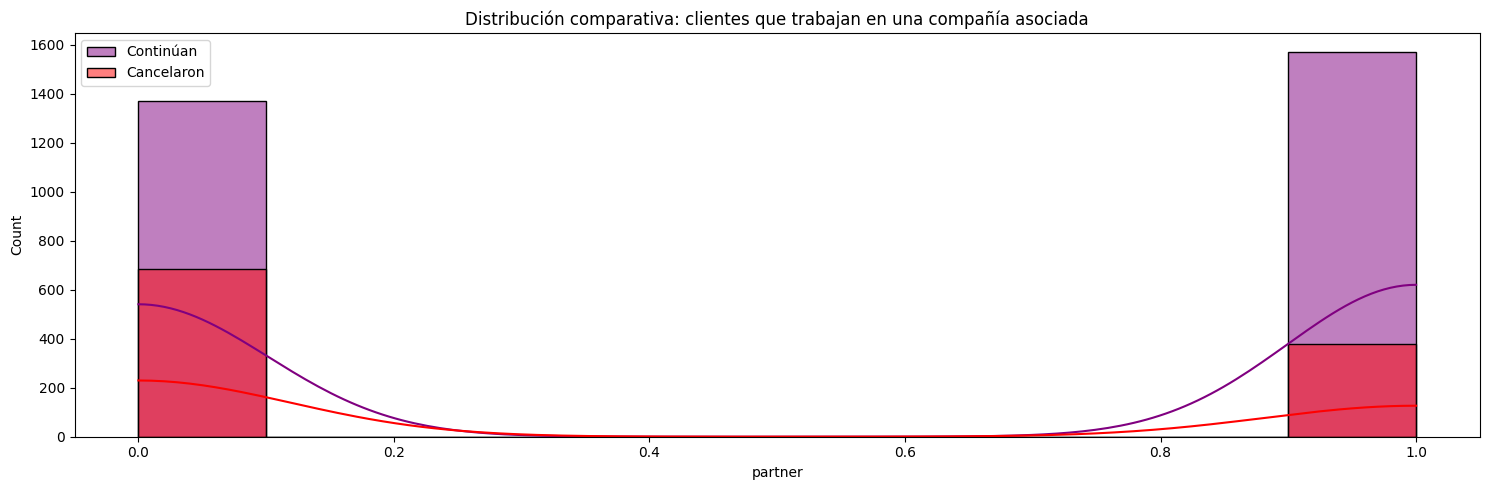

In [13]:
histograma_comparativo('partner', 'clientes que trabajan en una compañía asociada', 10, 10)
# 0 corresponde a que no trabajan en una compañía asociada y 1 que sí trabajan en una compañía asociada


Es mayor la cantidad de usuarios que pertenecen a una empresa asociada al gimnasio que continúan con su subscripción que los que cancelan.
Hay posibilidades de que quienes cancelan ya no estén empleados y por eso den de baja su subscripcion.

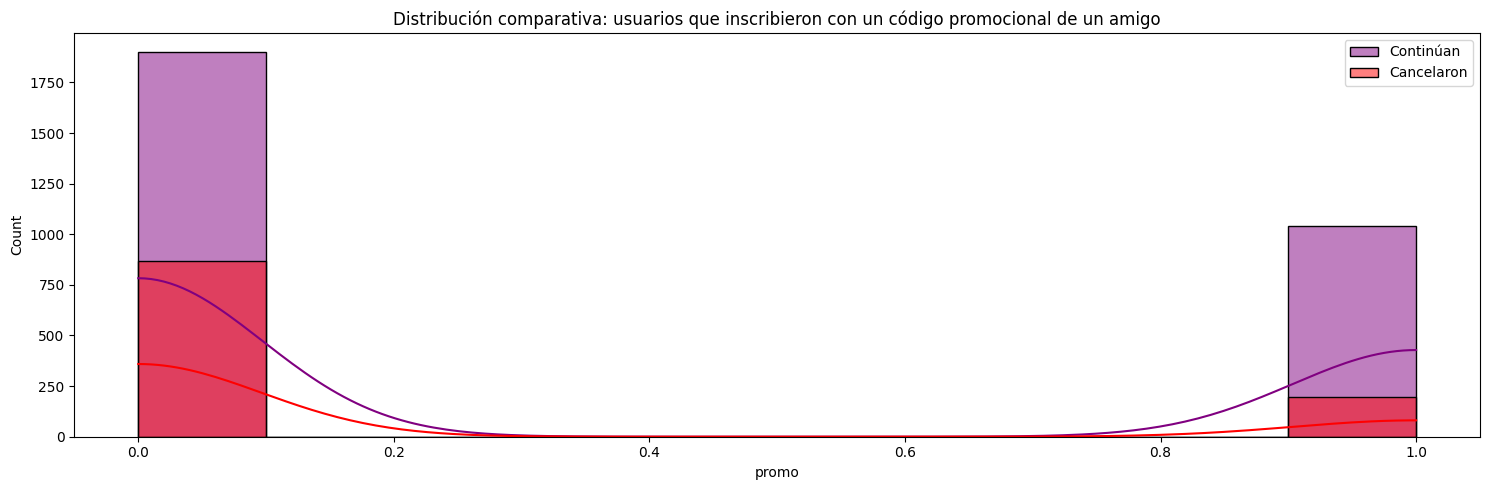

In [14]:
histograma_comparativo('promo', 'usuarios que inscribieron con un código promocional de un amigo', 10, 10)
# 0 corresponde a que no inscribieron con un código promocional de un amigo y 1 que sí inscribieron con un código promocional de un amigo


Son pocos los usuarios que cancelan su subscripción luego de haberse unido con un codigo promocional

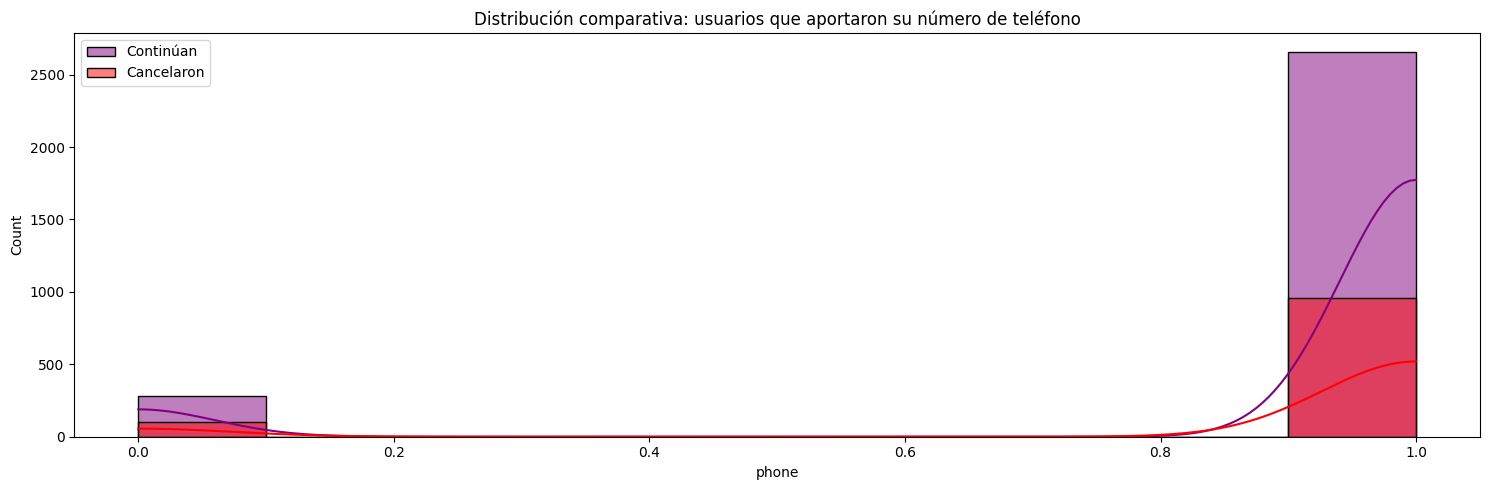

In [15]:
histograma_comparativo('phone', 'usuarios que aportaron su número de teléfono', 10, 10)
# 0 corresponde a que no aportaron su número de teléfono y 1 que sí aportaron su número de teléfono

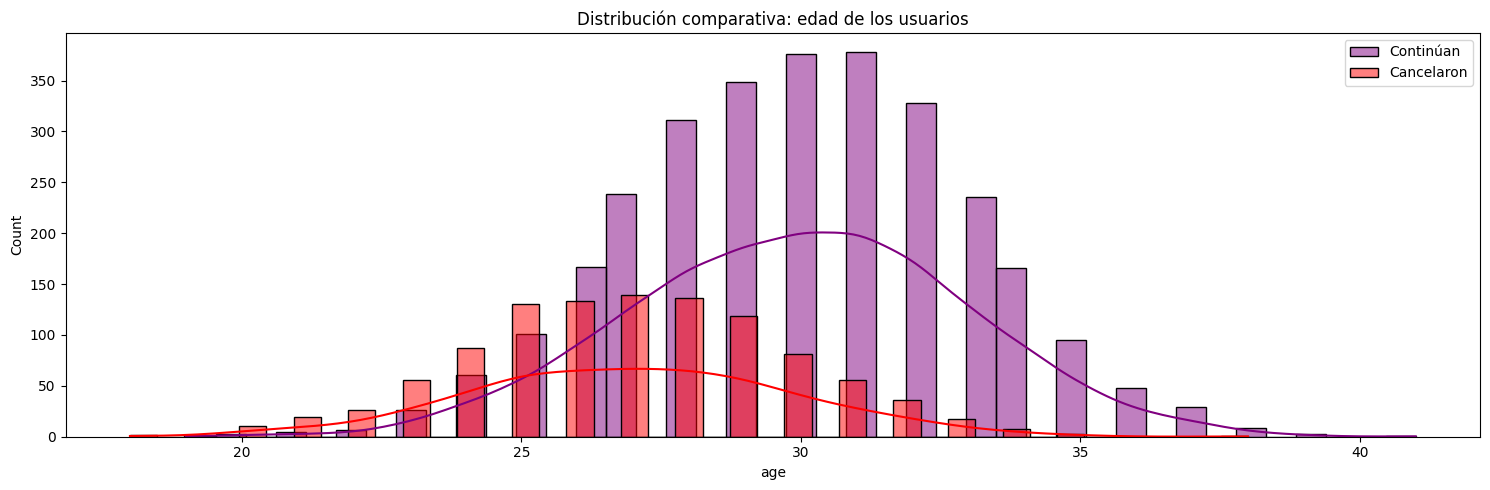

In [16]:
histograma_comparativo('age', 'edad de los usuarios', 41, 41)

Los usuarios que cancelan tienen un promedio de edad entre 26 y 27 años. Quienes continúan, tienen un promedio entre 30 y 32 años.

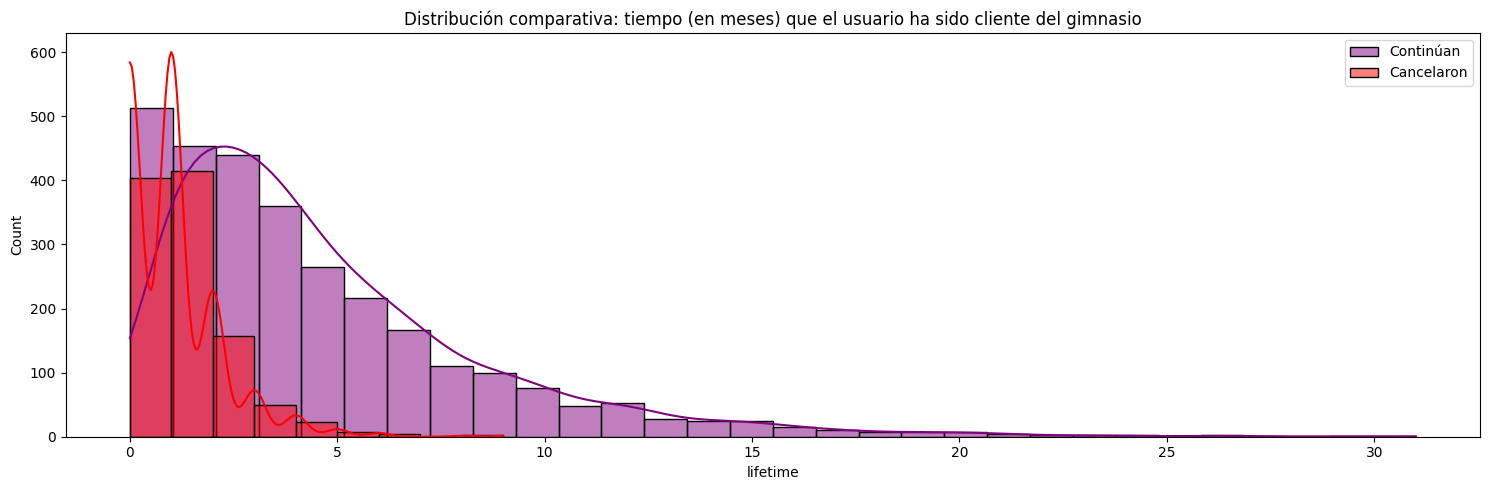

In [17]:
histograma_comparativo('lifetime', 'tiempo (en meses) que el usuario ha sido cliente del gimnasio', 30, 9)

El ciclo de vida de los usuarios que cancelan tiene mayor popularidad la duración de entre 1 y 2 meses con una maxima de 6/7 meses. Mientras que quienes continúan llegan a tener hasta 30 meses de subscrición. 

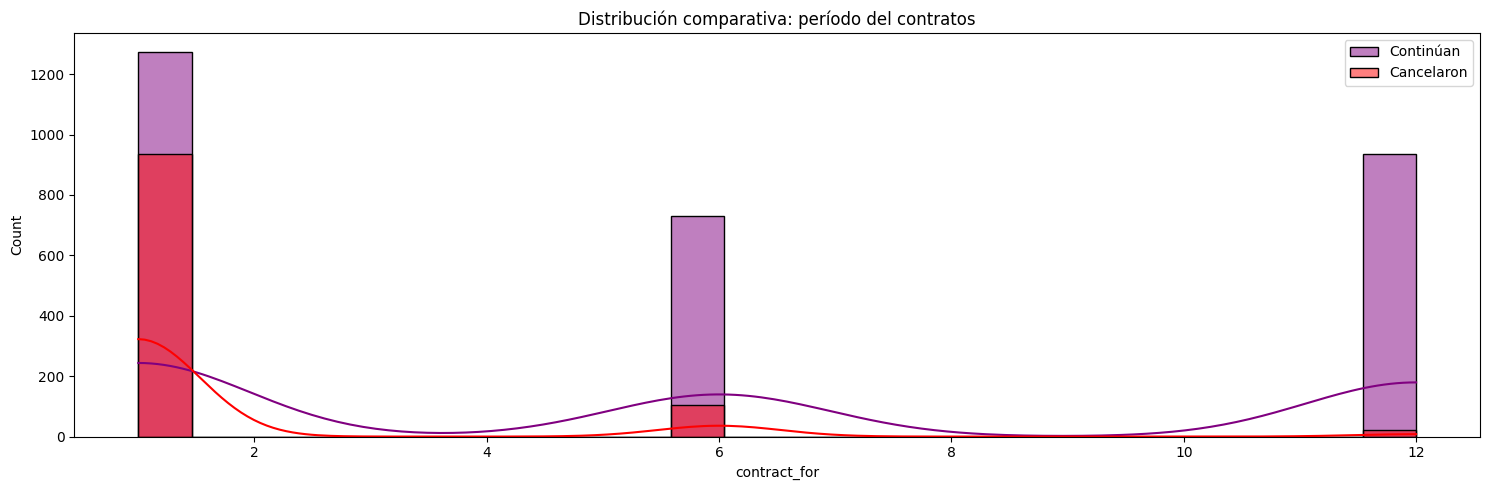

In [18]:
histograma_comparativo('contract_for', 'período del contratos', 24, 24)

La gran mayoría de los que cancelan es luego de tener contratos de 1 mes. Menos de 200 personas tienen contratos por 6 meses. Quienes continúan superan los 800 usuarios en cualquiera de los contratos por 1, 6 o 12 meses. 

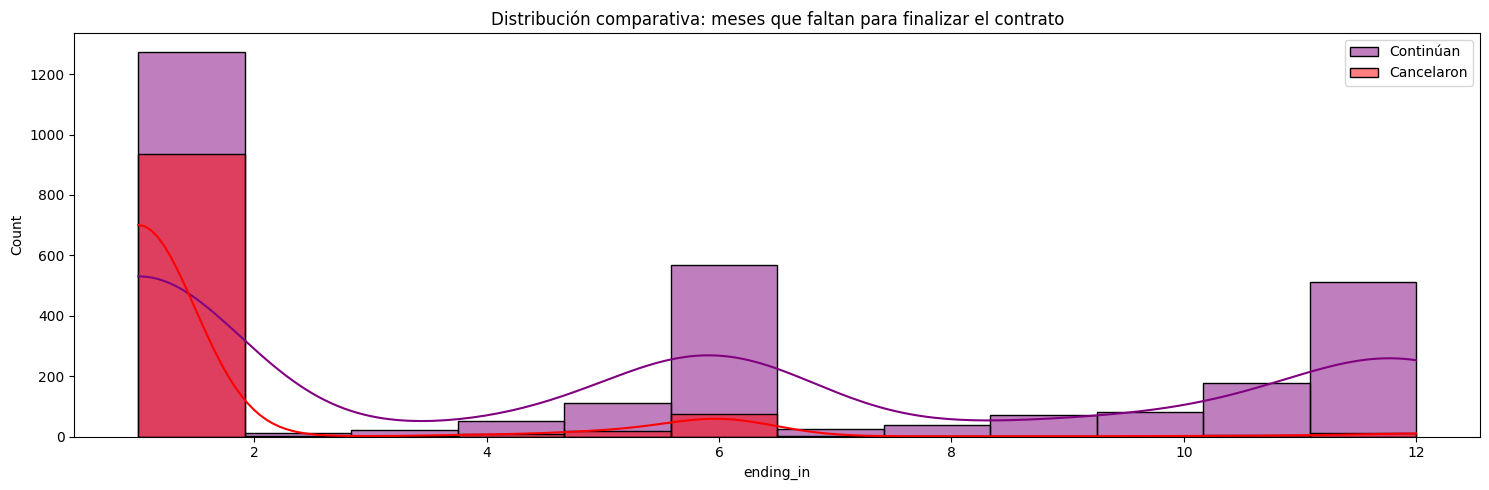

In [19]:
histograma_comparativo('ending_in', 'meses que faltan para finalizar el contrato', 12, 12)

Gran cantidad de usuarios cancelan su subscripción este mes: +800.

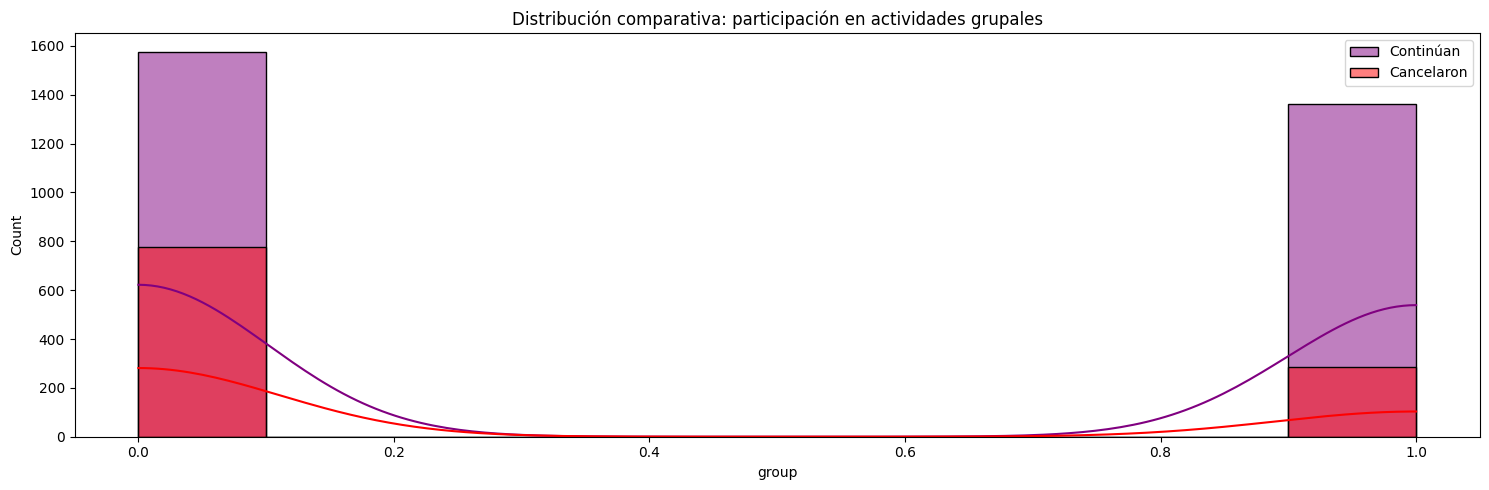

In [20]:
histograma_comparativo('group', 'participación en actividades grupales', 10, 10)
# 0 corresponde a que no participaron en actividades grupales y 1 que sí participaron en actividades grupales

Los usuarios que cancelan su subscripción tienen mayor tendencia a no asistir a las clases grupales. Aunque se observa que sucede lo mismo con quienes sí continúan con su contrato.

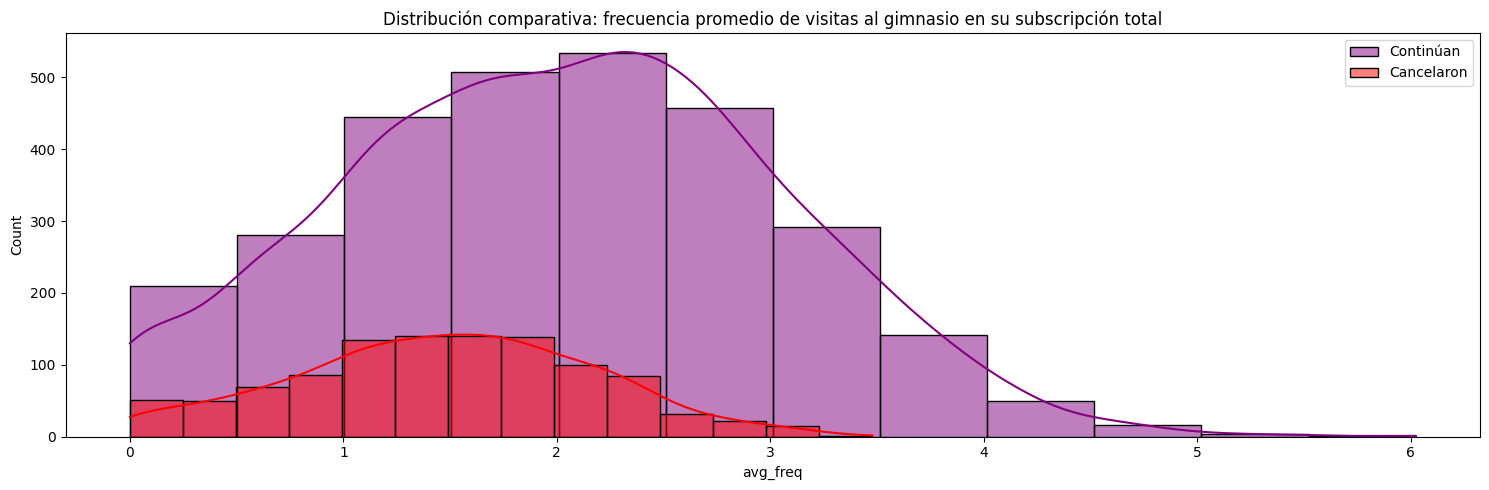

In [21]:
histograma_comparativo('avg_freq', 'frecuencia promedio de visitas al gimnasio en su subscripción total', 12, 14)

El promedio de visitas al gimnasio es entre 1 y 2 veces para los que cancelan su subscrición. Y quienes continúan, tienen un promedio de 2 veces.

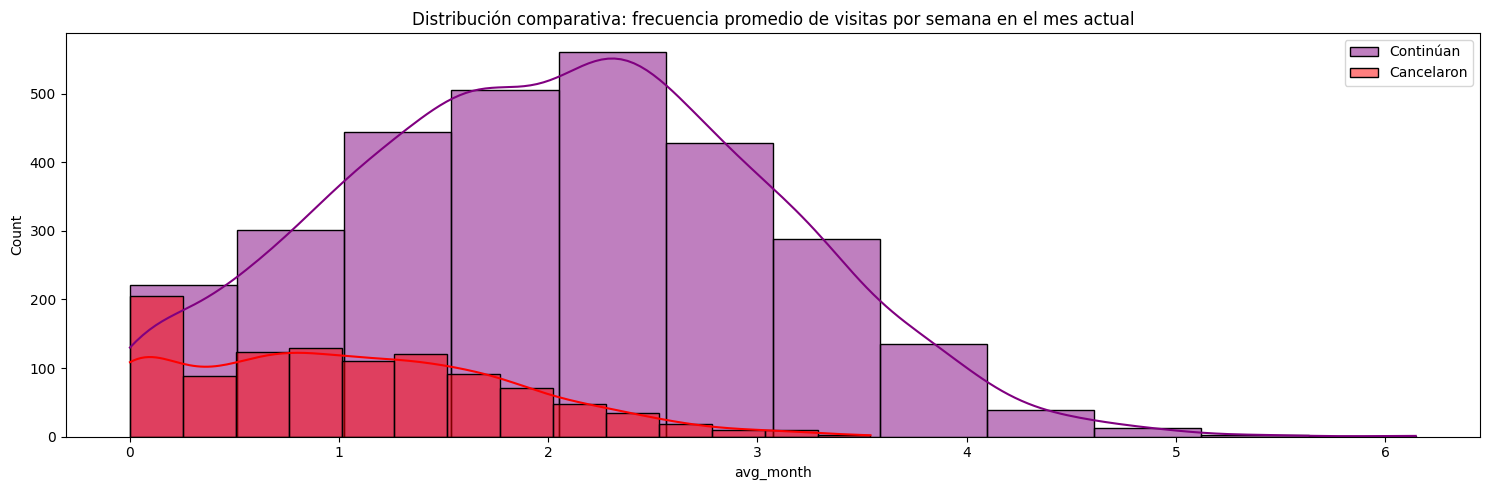

In [22]:
histograma_comparativo('avg_month', 'frecuencia promedio de visitas por semana en el mes actual', 12, 14)

Existe mayor asistencia al gym los usuarios que continúan con la subscrición que quienes cancelan.

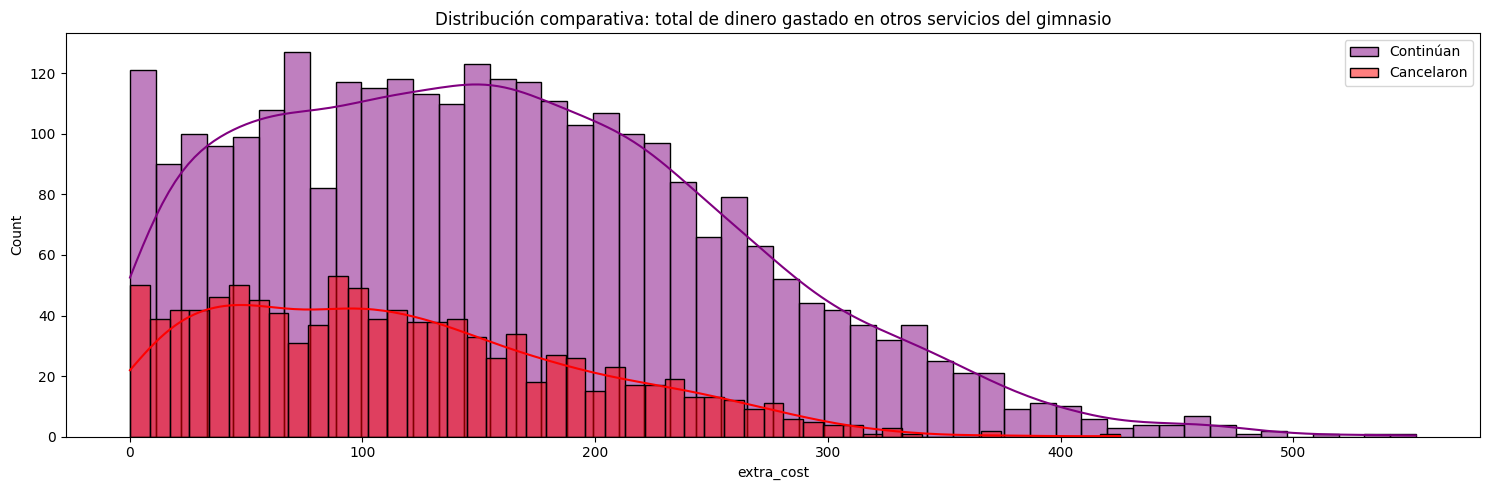

In [23]:
histograma_comparativo('extra_cost', 'total de dinero gastado en otros servicios del gimnasio', 50, 50)

Los que continúan tienen mayor cantidad de costos extras en el gimnasio que los que cancelan.

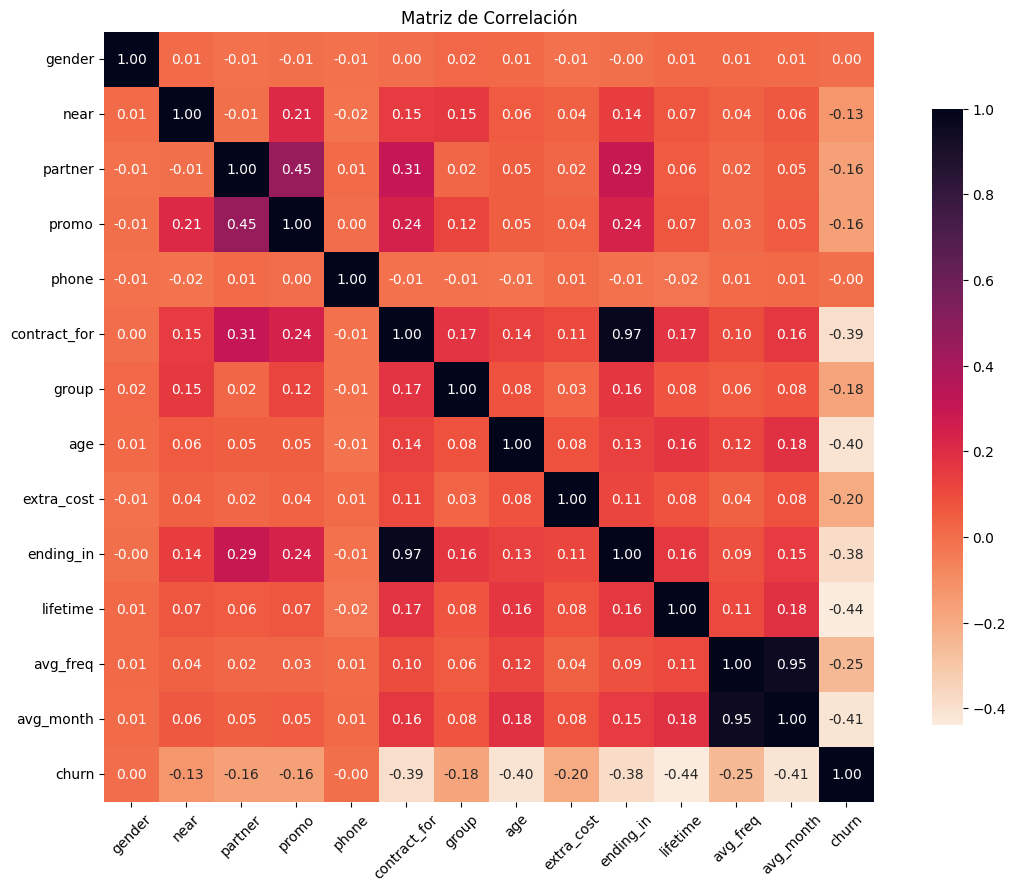

In [24]:
#Construimos y representamos una matriz de correlación para todo el conjunto de datos

cm = data.corr()
fig, ax = plt.subplots(figsize=(15, 10))

# Generamos un mapa de calor
sns.heatmap(cm, annot=True, fmt=".2f", cmap='rocket_r', square=True, ax=ax, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación')
plt.xticks(rotation=45)
plt.show()

No se observa, en el mapa de calor, una fuerte correlación positiva o negativa entre la cancelación de la subscripción y las características.

### 3° Etapa: Construimos un modelo para predecir la cancelación de usuarios

In [25]:
#Creamos un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

#Primero separamos la variable objetivo (y) del resto de las características (X)
y = data['churn']
X = data.drop('churn', axis=1)

#Dividimos los datos en conjuntos de entrenamiento y validación

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [26]:
#Entrenamos el modelo en el set de entrenamiento con regresión logística

#definimos algoritmo del modelo
model_lr = linear_model.LogisticRegression(max_iter=1000)

#entramos el modelo
model_lr.fit(X_train, y_train) 

#utilizamos el modelo para hacer predicciones en el conjunto de prueba
predictions_lr = model_lr.predict(X_test)
probabilities_lr = model_lr.predict_proba(X_test)[:,1]

#Evaluamos la exactitud, precisión y recall para el modelo:

print('Exactitud: {:.2f}'.format(accuracy_score(y_test, predictions_lr)))
print('Precisión: {:.2f}'.format(precision_score(y_test, predictions_lr)))
print('Recall: {:.2f}'.format(recall_score(y_test, predictions_lr)))

Exactitud: 0.92
Precisión: 0.86
Recall: 0.83


In [27]:
#Entrenamos el modelo en el set de entrenamiento con bosque aleatorio.

# definimos el algoritmo para el modelo
model_rf = RandomForestClassifier(random_state=0)

# entrenamos el modelo utilizando los datos de entrenamiento
model_rf.fit(X_train, y_train)

# hacemos pronósticos con el modelo entrenado
predictions_rf = model_rf.predict(X_test)

#Evaluamos la exactitud, precisión y recall para el modelo:

print('Exactitud: {:.2f}'.format(accuracy_score(y_test, predictions_rf)))
print('Precisión: {:.2f}'.format(precision_score(y_test, predictions_rf)))
print('Recall: {:.2f}'.format(recall_score(y_test, predictions_rf)))


Exactitud: 0.92
Precisión: 0.84
Recall: 0.81


Luego de las evaluaciones las métricas de clasificacion: exactitud, precision y recall, podemos decir que si bien ambos modelos superan el 80%, con una exactitud de más del 90%, el modelo de regresión logística supera al modelo de bosque aleatorio en precision y recall

### 4° Etapa. Clústeres de usuarios/as

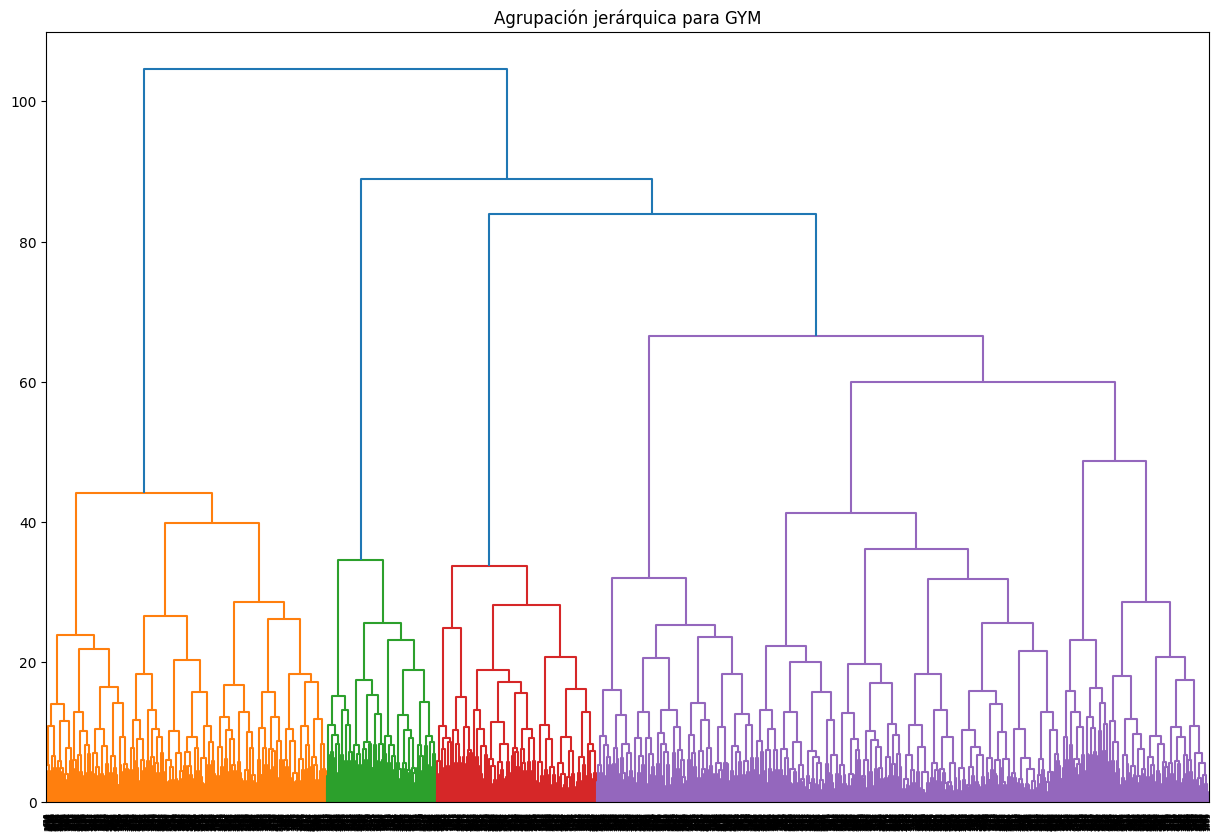

In [28]:
#estandarizamos los datos

# creamos un objeto de clase scaler (normalizador)
scaler = StandardScaler()

# entrenamos el normalizador y transformamos el conjunto de datos
X_sc = scaler.fit_transform(data.drop(columns = ['churn'])) 

#creamos una variable donde almacenamos la tabla con los haces de objetos vinculados
linked = linkage(X_sc, method = 'ward')

# graficamos el dendrograma
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica para GYM')
plt.show()


In [29]:
#K-means agrupa objetos paso por paso, teniendo en cuenta los colores del dendrograma el número óptimo de clústeres sugerido es 4.

km = KMeans(n_clusters = 4, random_state=0) 

# aplicamos el algoritmo a los datos y formar un vector de clúster
labels = km.fit_predict(X_sc) 

#almacenamos las etiquetas de clúster en el campo de nuestro conjunto de datos
data['cluster_km'] = labels

# obtiene las estadísticas de los valores medios de las características por clúster
data_cluster = data.groupby(['cluster_km']).mean()

display(data_cluster.sort_values(by='churn', ascending=False))


,gender,near,partner,promo,phone,contract_for,group,age,extra_cost,ending_in,lifetime,avg_freq,avg_month,churn
cluster_km,,,,,,,,,,,,,,
0,0.475868,0.806097,0.000000,0.082981,0.902625,1.828112,0.316681,28.196444,130.388619,1.755292,2.354784,1.340588,1.101768,0.547841
3,0.513761,0.753440,1.000000,0.446101,0.900229,2.574541,0.313073,28.510321,128.997012,2.383028,2.841743,1.371000,1.181216,0.400229
1,0.557018,0.875000,0.327851,0.210526,0.910088,2.794956,0.459430,30.226974,163.805504,2.588816,5.121711,2.924226,2.933171,0.044956
2,0.505314,0.941063,0.749758,0.536232,0.901449,11.373913,0.563285,29.960386,166.096558,10.414493,4.800966,2.000424,1.992218,0.023188


In [30]:
#El valor de la silueta muestra hasta qué punto un objeto de un clúster es similar a su clúster, en vez de otro. El valor oscila entre -1 y 1, 
#Un valor cercano a 0 indica que el objeto está en el límite entre dos clústeres.

# Calculamos el valor de la silueta para el agrupamiento

print('Silhouette_score: {:.2f}'.format(silhouette_score(X_sc, labels)))

Silhouette_score: 0.11


El valor de la silueta confirma que el objeto está en el límite entre los demás clusters. Sin embargo, pueden hacerse algunas conclusiones generales de lo observado en la tabla 'data_cluster':
- Dentro de Churn se observan 2 grupos con mayor tendencia a la cancelación de la subscripción (0 y 3),en comparación con los clusters  1 y 2 donde se observa mayor 'lealtad'. Se pueden ver ciertas diferencias entre quienes deciden abandonar y quienes continúan su subscripcion:
    -   Quienes abandonan asisten a menor cantidad de clases grupales.
    -   La edad promedio es de 28 años de quienes cancelan su membresía, mientras que quienes continúan es de 30.
    -   Tienen menor cantidad de gastos extras en las instalaciones quienes pertenecen al grupo 0 y 3.
    -   Los contratos de quienes abandonan suelen ser más cortos (entre 1 y 3 meses), esta característica está relacionada también con cuánto falta para que su contrato finalice que al mismo tiempo afecta el lifetime, siendo menor que con los otros clusters.
    -   La frecuencia con la que van a las instalaciones en ambos casos: total y el último mes, es menor, que quienes continúan.


Otra observación, es que quienes abandonan, residen o no en una empresa asociada con el gym, se observan los dos extremos: o trabajan o no trabajan.
Tambien se observa numero extremo en el cluster 2, en contrat_for, comparado con el resto de los clusters. En el mismo cluster, en el sector ending_in tambien se encuentra un numero extremo. Esto se debe a la cantidad de meses seguramente, entre cúanto dura una subscripcion y cuanto falta para que termine.

In [31]:
#Creamos función para representar gráficos de características pareadas para los clústeres
def show_clusters(df, x_name, y_name, cluster_name, w, l, titulo):
    plt.figure(figsize=(w, l))
    sns.scatterplot(x=df[x_name], y=df[y_name], hue=df[cluster_name], palette='rocket_r')
    plt.title('{}'.format(titulo))
    plt.show()


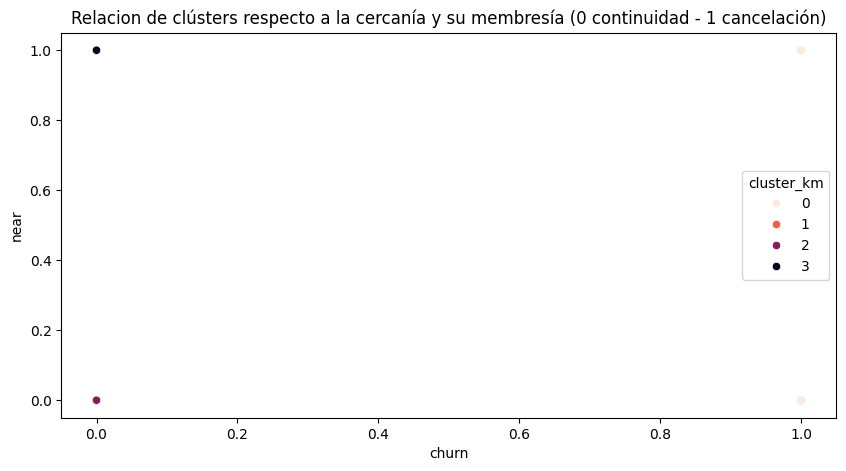

In [32]:
show_clusters(data, 'churn', 'near','cluster_km', 10, 5, 'Relacion de clústers respecto a la cercanía y su membresía (0 continuidad - 1 cancelación)')

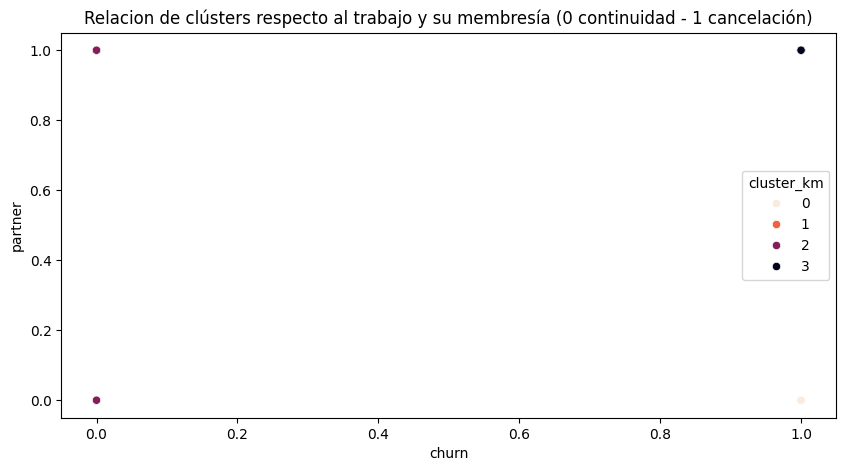

In [33]:
show_clusters(data, 'churn', 'partner','cluster_km', 10, 5, 'Relacion de clústers respecto al trabajo y su membresía (0 continuidad - 1 cancelación)')

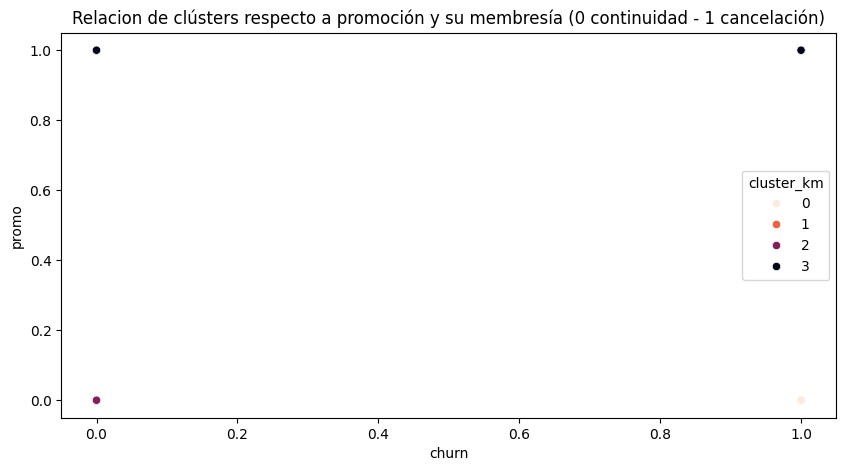

In [34]:
show_clusters(data, 'churn', 'promo','cluster_km', 10, 5, 'Relacion de clústers respecto a promoción y su membresía (0 continuidad - 1 cancelación)')

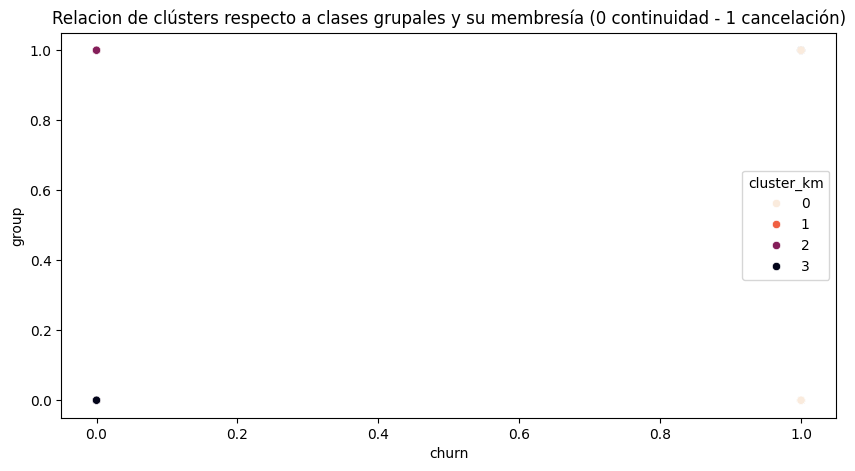

In [ ]:
show_clusters(data, 'churn', 'group','cluster_km', 10, 5, 'Relacion de clústers respecto a clases grupales y su membresía (0 continuidad - 1 cancelación)')

Parte de como se han dividio estos clusters pareciera tener relacion con las características: cercania al gym, clases grupales, codigos promocionales y si el trabajo tiene un convenio con la institución.

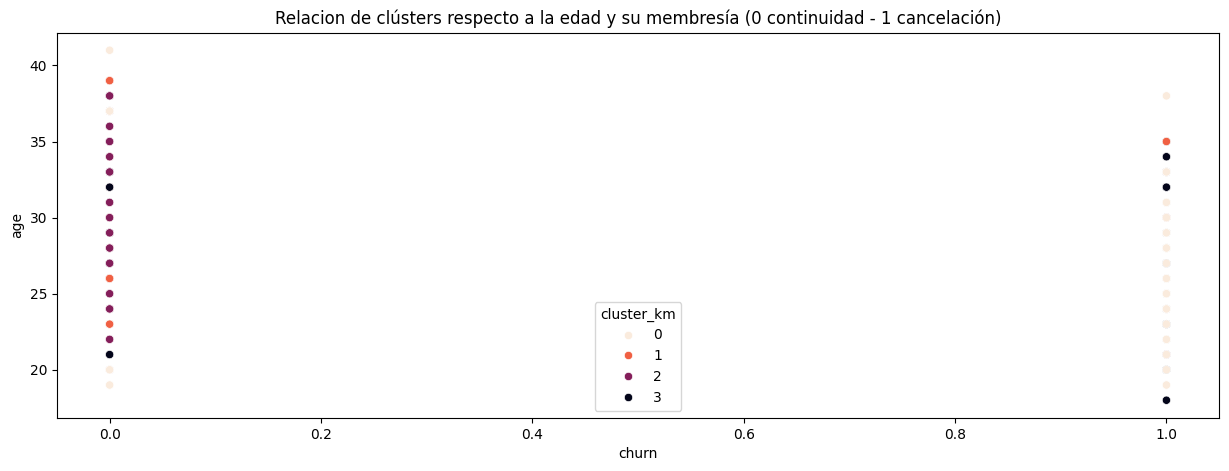

In [36]:
# Representamos el gráfico para las características pareadas de cluster
show_clusters(data, 'churn', 'age','cluster_km', 15, 5, 'Relacion de clústers respecto a la edad y su membresía (0 continuidad - 1 cancelación)')

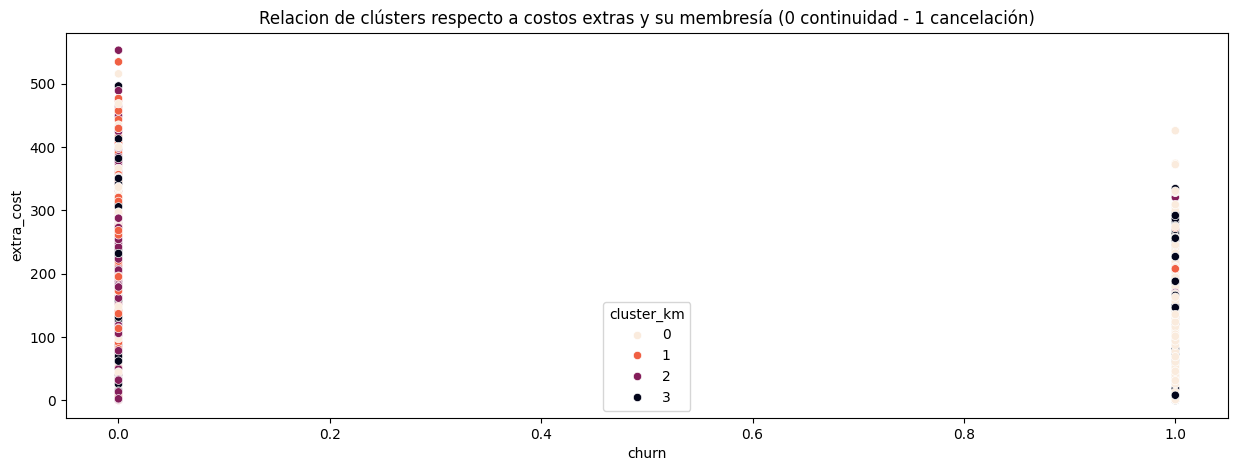

In [37]:

# Representamos el gráfico para las características pareadas de cluster
show_clusters(data, 'churn', 'extra_cost','cluster_km', 15, 5, 'Relacion de clústers respecto a costos extras y su membresía (0 continuidad - 1 cancelación)')

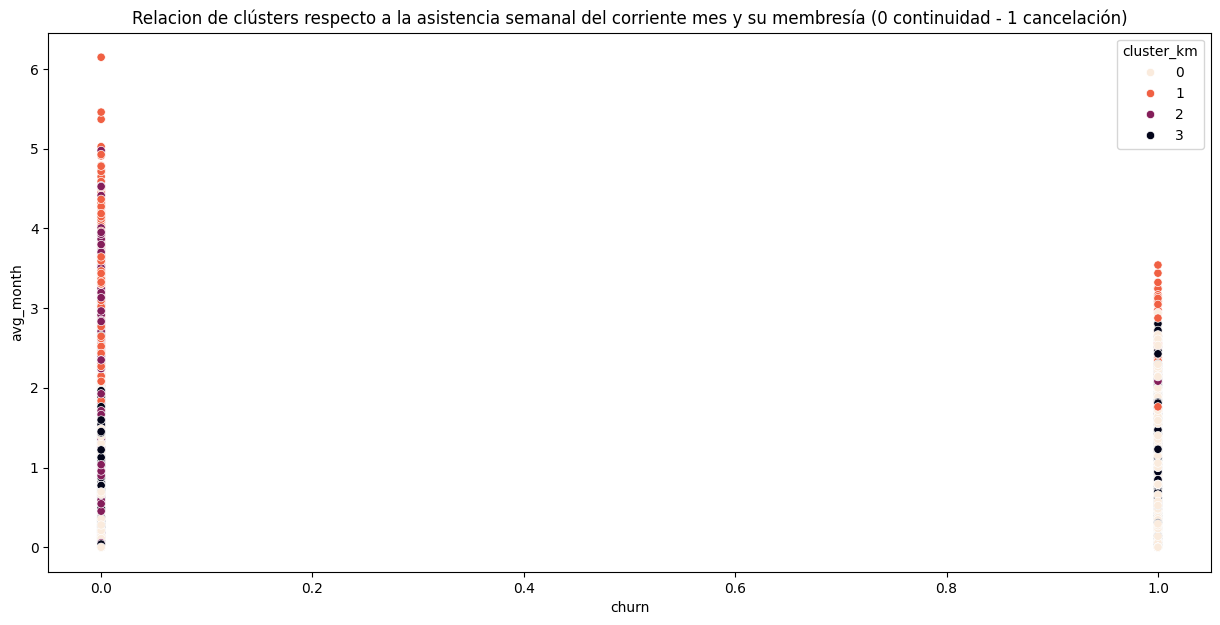

In [38]:
show_clusters(data, 'churn', 'avg_month','cluster_km', 15, 7, 'Relacion de clústers respecto a la asistencia semanal del corriente mes y su membresía (0 continuidad - 1 cancelación)') 

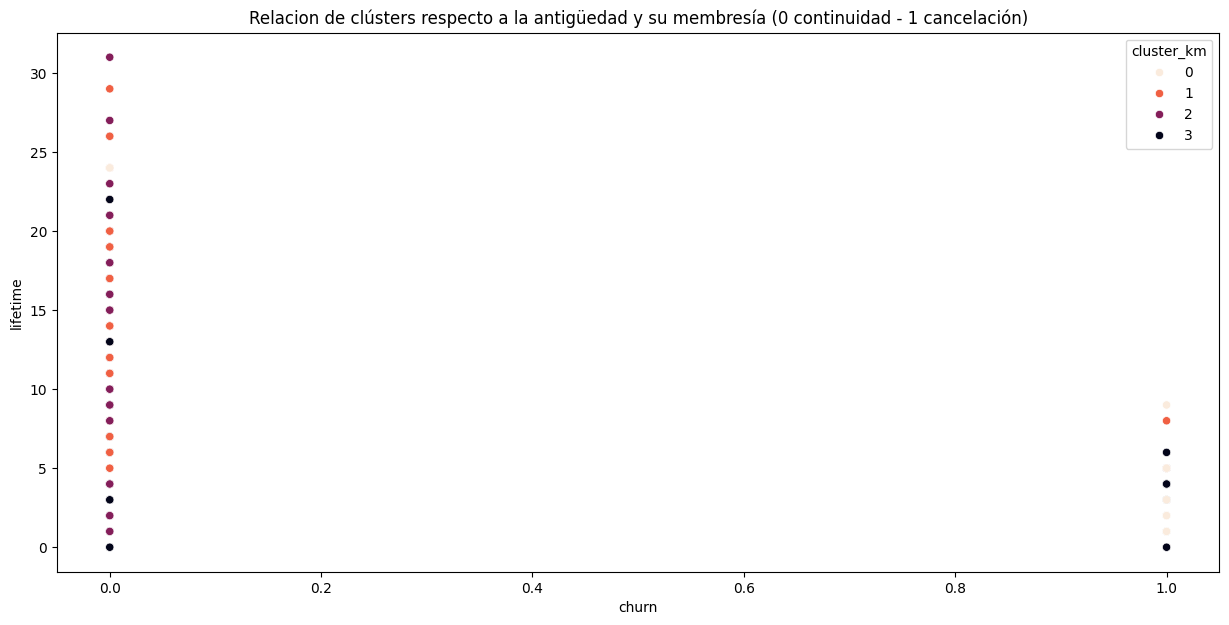

In [39]:
show_clusters(data, 'churn', 'lifetime','cluster_km', 15, 7, 'Relacion de clústers respecto a la antigüedad y su membresía (0 continuidad - 1 cancelación)') 

En los graficos representados arriba se observa como los clusteres 0 y 3 sobresalen entre los miembros que desean cancelar. Y como los clusteres 1 y 2 se asocian más a quienes continúan con su membresía.

### 5° Etapa: Conclusiones y recomendaciones básicas sobre el trabajo con clientes

Luego de lo analizado en este proyecto podemos llegar a las siguientes conclusiones en cuanto a los clientes que deciden cancelar su subscripción, hay una tendencia en ellos a:
- Se subscriben a contratos más cortos de 1 o 3 meses;
- Generar menos gastos dentro de las instalaciones;
- Asisten con menor frecuencia el último mes por semana y a las clases grupales;
- La edad promedio es menor que la de quienes continúan.


También se pudo observar que muchos de los que cancelan viven lejos del área donde se ubica el gimnasio. Pero además, quienes acceden con un código promocional o trabajan en una companía que tiene convenio con el gimnasio tienen menor tendencia a cancelar su subscripción. 

Por lo tanto, teniendo en cuenta estas observaciones, puede decirse que lo que signifique un 'descuento' para el cliente genera cierta lealtad. Para incrementar la clientela, teniendo en cuenta esta conclusión, se recomienda:
-  Hacer campañas en los barrios donde se ubican los gimnasios y ofrecer códigos promocionales: matrícula gratis, meses de descuento, etc.
- Incrementar relaciones / asociaciones con empresas a las que se les beneficia a sus empleados con descuentos.
- Continuar con los codigos promocionales para amigos.